In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import scvi

import seaborn as sns

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

# RNA clustering

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

union_bc_file = os.path.join(Union_cell_subdir, 'Union_cell_3set.tsv')
union_bc_df = pd.read_csv(union_bc_file,  sep='\t', index_col=0)
union_bc_df.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy
atac_bc,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451


In [3]:
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')
h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [5]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"

scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna_union, layer="counts")
vae = scvi.model.SCVI(h5_rna_union, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
# h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
# sc.tl.umap(h5_rna_union, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers whi

Epoch 400/400: 100%|██████████| 400/400 [01:44<00:00,  5.00it/s, v_num=1, train_loss_step=4.71e+3, train_loss_epoch=4.8e+3] 

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:44<00:00,  3.83it/s, v_num=1, train_loss_step=4.71e+3, train_loss_epoch=4.8e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_2898417/2278249897.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)


In [ ]:
col_list = ['rna_barcodes', 'atac_barcodes', 
            'rna_pass_CR', 
            'leiden_RNA_scVI', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 
            'N_MT_counts', 'MT%', 
            ]
# Save RNA clusteirng results
rna_info_file = os.path.join(Union_cell_subdir, 'Union_3set_rna_info.tsv')
h5_rna_union.obs[col_list].to_csv(rna_info_file, sep='\t', index=False)

### Vis on RNA spcae

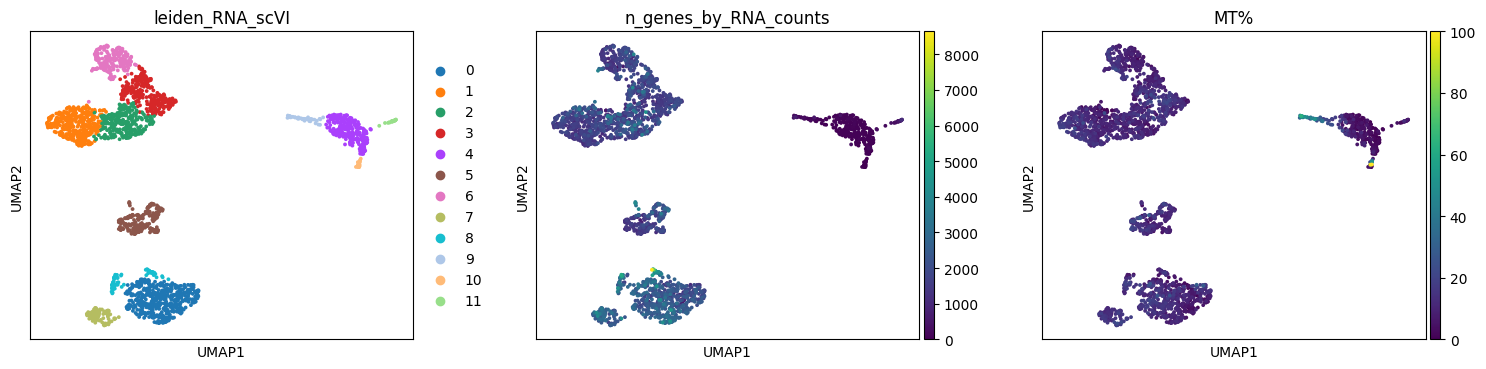

In [7]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI',  'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=3)

In [8]:
print('Total number of barcodes that pass at least one of the three ATAC-based filtering methods: ', union_bc_df.shape[0])
print('Among those barcodes, number of barcodes that has RNA information: ', h5_rna_union.shape[0])

Total number of barcodes that pass at least one of the three ATAC-based filtering methods:  2384
Among those barcodes, number of barcodes that has RNA information:  2381


In [9]:
# 3 cells do not have RNA info at all 
bc_wo_RNAinfo_list = union_bc_df.index[~union_bc_df.index.isin(h5_rna_union.obs['atac_barcodes'])]
union_bc_df.loc[bc_wo_RNAinfo_list]

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy
atac_bc,,,,,,,,,
CGAATAATCTCACTTC,1377,False,True,False,entropy_only,entropy_only,ACACTTAAGTGATTCA,False,0.169662
CGGTTTATCCTAAATC,1236,False,True,False,entropy_only,entropy_only,ATGGCTTAGGAGCAAC,False,0.242614
GTTAGGAGTGCTCATG,352,False,True,False,entropy_only,entropy_only,CCTGTAACAACTGGGA,False,0.087141


In [10]:
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'Entropy']
if 'Entropy' not in h5_rna_union.obs.columns:
    h5_rna_union.obs = h5_rna_union.obs.merge(union_bc_df[col_list],left_on='atac_barcodes', right_index=True, how='left')

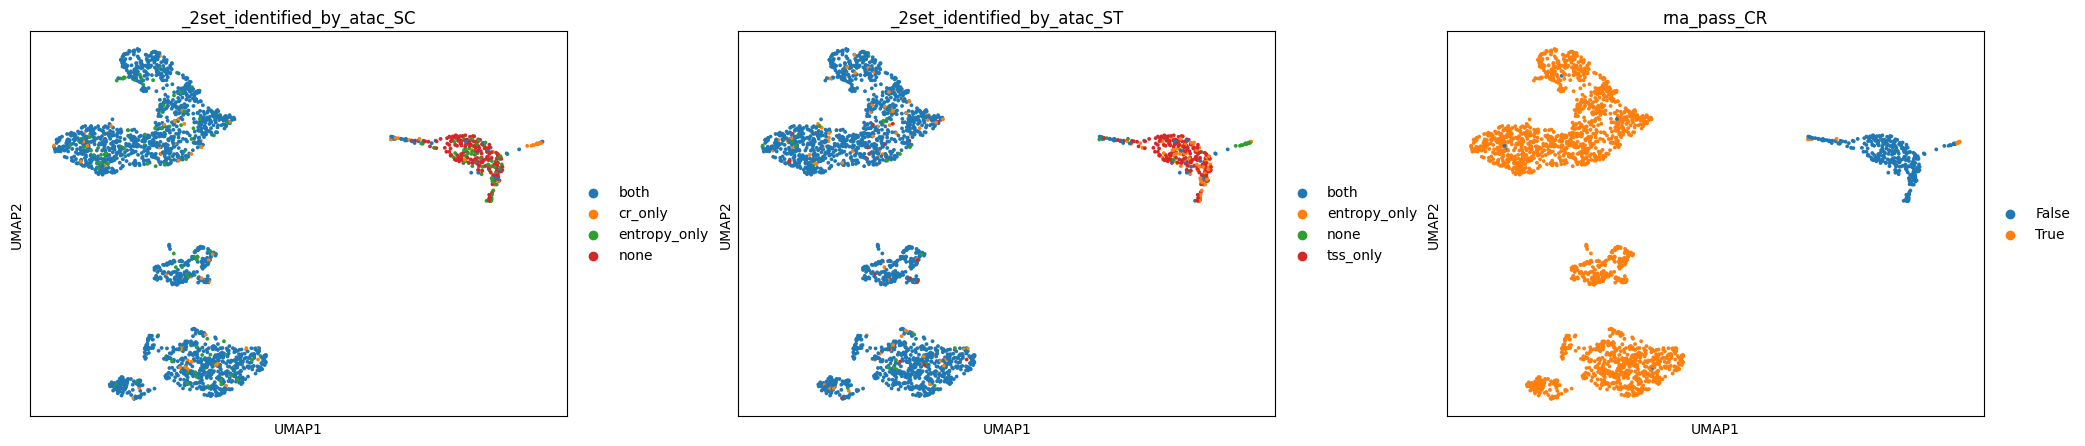

In [11]:

with plt.rc_context({'figure.figsize': (7, 5)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC',
                                    '_2set_identified_by_atac_ST', 
                              'rna_pass_CR'], wspace=0.2, size=30, ncols=3)

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

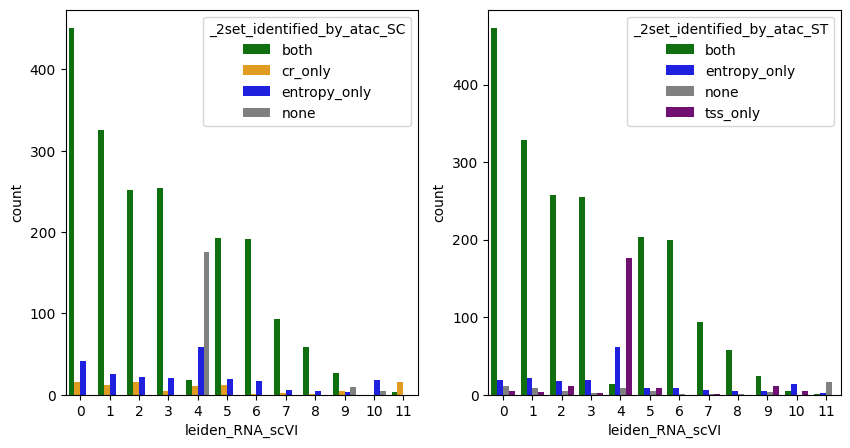

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
color_dic = {'both': 'green', 'entropy_only': 'blue', 'cr_only': 'orange',   'tss_only': 'purple', 'none': 'grey', '2 out of 3': 'cyan', 'all': 'red'}
sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_SC', palette=color_dic, ax=ax[0])
sns.countplot(data=h5_rna_union.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_ST', palette=color_dic, ax=ax[1])


In [ ]:
union_bc_df['leiden_RNA_scVI'] = union_bc_df.index.map(h5_rna_union.obs.set_index('atac_barcodes')['leiden_RNA_scVI'])
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].cat.add_categories('no_rna_info')
union_bc_df['leiden_RNA_scVI'] = union_bc_df['leiden_RNA_scVI'].fillna('no_rna_info')

union_cell_info_w_RNAcluster_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster.tsv')
union_bc_df.to_csv(union_cell_info_w_RNAcluster_file, sep='\t')
union_bc_df['leiden_RNA_scVI'].value_counts()

leiden_RNA_scVI
0              508
1              363
2              289
3              278
4              261
5              224
6              209
7              101
8               63
9               43
10              23
11              19
no_rna_info      3
Name: count, dtype: int64

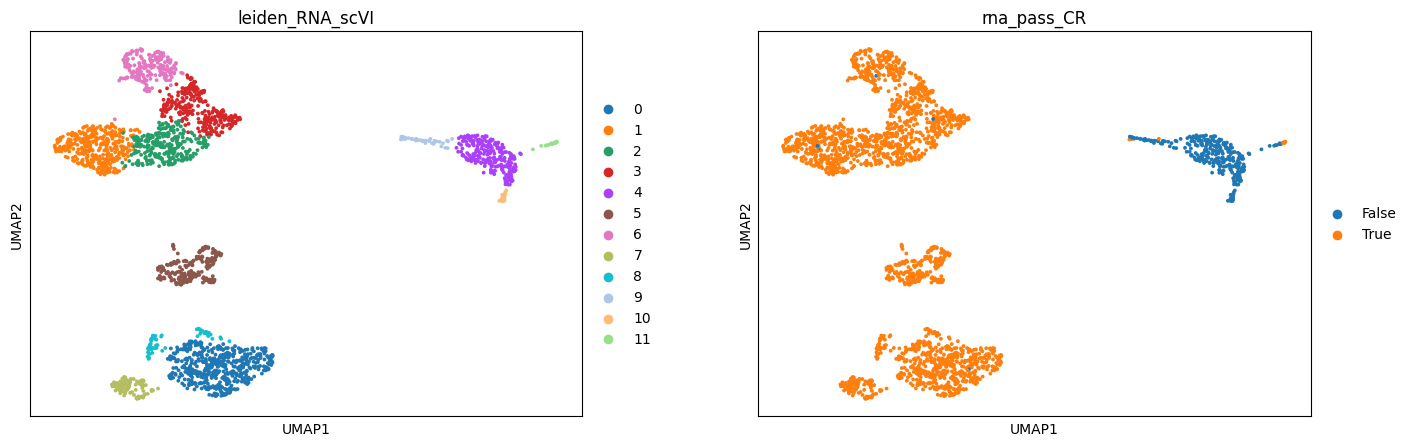

In [14]:

with plt.rc_context({'figure.figsize': (7, 5)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI', 
                              'rna_pass_CR'], wspace=0.2, size=30, ncols=3)